# 06 日盘五分钟成交强度

本 Notebook 复现论文 Figure 15：把同一品种全部固定月份合约的一分钟成交量先按时刻汇总，再在每个日盘 Session 内形成五分钟成交量，占当日全部日盘成交量的比例；按 2016–17、2018–19、2020–21 三个窗口展示单日散点、跨日均值和 25%–75% 分位带。

数据只从正式 silver 湖仓读取；所有结果仅保存在 Notebook 输出中，不写入 silver、gold 或其他数据文件。

## 在做什么

一天内的交易并非均匀发生。本项先把同一品种当时所有合约的成交量相加，再比较每个五分钟桶占当日日盘总成交量的比例。

- 灰点：某个交易日在某个五分钟桶的成交量占比。
- 蓝线：同一两年窗口中该时点占比的跨日均值。
- 红色带：同一时点跨日分布的 25%–75% 分位区间。
- 三段曲线之间的空白是真实休市间隔，不跨 Session 拼接五分钟桶。

## 经济意义

成交强度描述订单流在交易日内如何集中。开盘附近较高通常与隔夜信息和积压订单释放有关；收盘前抬升可能反映风险调整、平仓和基准时点执行。分位带越宽，说明该时点在不同交易日之间的活跃度越不稳定。

该比例只描述成交量的日内分配，不直接衡量买卖价差、市场深度或交易成本。开收盘形态也不能单独证明算法交易导致了市场质量变化。

## 论文口径与当前实现

论文 Figure 15 按 2016–17、2018–19、2020–21 三个窗口展示日盘五分钟成交强度，并排除夜盘。正文和图注把指标表述为“五分钟成交量占当日总成交量的百分比”；附录公式额外写入了半秒快照数的平均因子，但这与图中约 1%–5% 的纵轴不一致。本 Notebook 依照正文、图注和项目计划，使用五分钟成交量之和除以当日日盘成交量。

原论文使用半秒数据；当前分钟事实保存完整的一分钟成交量。只要一分钟成交量覆盖该五分钟区间，先按分钟求和与直接从更高频成交量求五分钟总量在加总意义上等价，但无法检查五分钟内部的半秒路径。

## 数据覆盖与适用边界

- 当前 fact_futures_minute 在论文日内样本中覆盖 RB、CU、NI、L；M、C 没有分钟事实，因此不创建伪造曲线。
- 使用 dim_futures_contract_calendar 的 is_night_session=false 识别日盘，不用硬编码小时范围猜测 Session。
- 湖仓权威日盘规则为 09:00–10:15、10:30–11:30、13:30–15:00。论文正文写 09:30 开始，但原图横轴与当前权威合约日历均从 09:00 开始，本项依照可执行日历。
- minute bar_at 是右闭区间的分钟结束时刻；五分钟桶在每个 Session 起点后独立编号，绝不跨 10:15–10:30 或 11:30–13:30 的休市间隔。
- 成交量先跨全部固定月份合约汇总，不只选择主力合约。

## 代码步骤

1. 定位项目根目录并导入权威合约日历与分钟事实 Schema。
2. 设置日内样本、三个两年窗口、四个可用品种和图表边界。
3. 从 Schema metadata 定位两张 silver 表并检查六品种分钟覆盖。
4. 契约化读取合约 Session，构造按品种—交易日—Session 唯一的日盘时刻表。
5. 按品种—年份分块读取分钟成交量，先跨合约汇总一分钟，再构造 Session 内五分钟桶和日占比。
6. 输出数据覆盖和开盘/收盘相对中段强度表。
7. 绘制 4×3 的 Figure 15 风格图。
8. 验证 Session、成交量守恒、日占比、分位数和图表结构。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import pathlib
import sys
from datetime import date

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import (  # noqa: E402
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    arrow_to_pandas,
)
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(
    "schema_tables: "
    f"{FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b'table_name'].decode('utf-8')}, "
    f"{FUTURES_MINUTE_SCHEMA.metadata[b'table_name'].decode('utf-8')}"
)

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_tables: dim_futures_contract_calendar, fact_futures_minute


## 第 2 步：设置论文样本、窗口和图表参数

日期参数可以在湖仓覆盖范围内调整。面板窗口仍由 ANALYSIS_PERIODS 明确配置；12% 纵轴覆盖当前数据的全部均值与四分位带，超过上限的极端单日灰点只在图中裁切，计算和分位数不裁切，并单独报告数量。

In [2]:
PAPER_START_DATE = date(2016, 1, 1)
PAPER_END_DATE = date(2021, 12, 31)
ANALYSIS_START_DATE = PAPER_START_DATE
ANALYSIS_END_DATE = PAPER_END_DATE
FIVE_MINUTE_SIZE = 5
FIGURE_Y_MAX_SHARE = 0.12

ANALYSIS_PERIODS = [
    {"label": "2016-17", "start_year": 2016, "end_year": 2017},
    {"label": "2018-19", "start_year": 2018, "end_year": 2019},
    {"label": "2020-21", "start_year": 2020, "end_year": 2021},
]
PERIOD_LABELS = [period["label"] for period in ANALYSIS_PERIODS]
PERIOD_BY_YEAR = {
    year: period["label"]
    for period in ANALYSIS_PERIODS
    for year in range(period["start_year"], period["end_year"] + 1)
}
EXPECTED_YEARS_BY_PERIOD = {
    period["label"]: tuple(range(period["start_year"], period["end_year"] + 1))
    for period in ANALYSIS_PERIODS
}

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"},
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},
]
UNAVAILABLE_PRODUCTS = [
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"},
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},
]
ALL_PAPER_PRODUCTS = [*PRODUCTS, *UNAVAILABLE_PRODUCTS]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}
CLOCK_TICKS = [9 * 60, 10 * 60 + 15, 10 * 60 + 30, 11 * 60 + 30, 13 * 60 + 30, 15 * 60]
CLOCK_TICK_LABELS = ["09:00", "10:15\n", "\n10:30", "11:30", "13:30", "15:00"]

if ANALYSIS_START_DATE > ANALYSIS_END_DATE:
    raise ValueError("分析起始日不得晚于结束日")
if FIVE_MINUTE_SIZE <= 0:
    raise ValueError("五分钟桶宽必须为正")
if not 0 < FIGURE_Y_MAX_SHARE <= 1:
    raise ValueError("图表纵轴上限必须位于 (0, 1]")

display(pd.DataFrame(PRODUCTS))
display(pd.DataFrame(UNAVAILABLE_PRODUCTS).assign(reason="分钟事实缺失，不绘图"))
print(f"analysis_dates: {ANALYSIS_START_DATE} to {ANALYSIS_END_DATE}")
print(f"periods: {PERIOD_LABELS}")
print(f"figure_y_max: {FIGURE_Y_MAX_SHARE:.0%}")

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,L,Plastic


,exchange_code,underlying_code,label,reason
0,XDCE,M,Soybean Meal,分钟事实缺失，不绘图
1,XDCE,C,Corn,分钟事实缺失，不绘图


analysis_dates: 2016-01-01 to 2021-12-31
periods: ['2016-17', '2018-19', '2020-21']
figure_y_max: 12%


## 第 3 步：定位两张 silver 表并检查分钟覆盖

表名与 Hive 分区顺序只从权威 Schema metadata 读取一次。PyArrow Dataset 先按交易所、品种和年份下推过滤；M、C 的零行结果用于确认当前复现边界。

In [3]:
calendar_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata or {}).items()
}
minute_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_MINUTE_SCHEMA.metadata or {}).items()
}
calendar_path = (
    settings.futures_lake_root / "silver" / calendar_metadata["table_name"]
)
minute_path = settings.futures_lake_root / "silver" / minute_metadata["table_name"]
for table_path in [calendar_path, minute_path]:
    if not table_path.exists():
        raise FileNotFoundError(f"silver 表不存在：{table_path}")

calendar_partition_columns = calendar_metadata["partition_columns"].split(",")
minute_partition_columns = minute_metadata["partition_columns"].split(",")
calendar_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name).type)
        for column_name in calendar_partition_columns
    ]
)
minute_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_MINUTE_SCHEMA.field(column_name).type)
        for column_name in minute_partition_columns
    ]
)
calendar_dataset = ds.dataset(
    calendar_path,
    format="parquet",
    partitioning=ds.partitioning(calendar_partitioning_schema, flavor="hive"),
)
minute_dataset = ds.dataset(
    minute_path,
    format="parquet",
    partitioning=ds.partitioning(minute_partitioning_schema, flavor="hive"),
)

calendar_columns = [
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "volume",
]
calendar_required_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in calendar_columns]
)
minute_required_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
for required_schema, source_dataset in [
    (calendar_required_schema, calendar_dataset),
    (minute_required_schema, minute_dataset),
]:
    for expected_field in required_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if actual_field.type != expected_field.type:
            raise TypeError(
                f"字段 {expected_field.name} 类型不匹配："
                f"期望 {expected_field.type}，实际 {actual_field.type}"
            )

analysis_years = list(range(ANALYSIS_START_DATE.year, ANALYSIS_END_DATE.year + 1))
six_product_coverage_records = []
for product in ALL_PAPER_PRODUCTS:
    product_filter = (
        (ds.field("exchange_code") == product["exchange_code"])
        & (ds.field("underlying_code") == product["underlying_code"])
        & (ds.field("year") >= ANALYSIS_START_DATE.year)
        & (ds.field("year") <= ANALYSIS_END_DATE.year)
        & (ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE))
        & (ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE))
    )
    six_product_coverage_records.append(
        {
            **product,
            "minute_fact_rows": minute_dataset.count_rows(filter=product_filter),
        }
    )

six_product_minute_coverage_df = pd.DataFrame(six_product_coverage_records)
six_product_minute_coverage_df["status"] = np.where(
    six_product_minute_coverage_df["minute_fact_rows"] > 0,
    "可复现",
    "无分钟事实",
)
display(six_product_minute_coverage_df)
print(f"calendar_path: {calendar_path}")
print(f"minute_path: {minute_path}")

,exchange_code,underlying_code,label,minute_fact_rows,status
0,XSGE,RB,Steel Rebar,6012540,可复现
1,XSGE,CU,Copper,7861500,可复现
2,XSGE,NI,Nickel,7861500,可复现
3,XDCE,L,Plastic,4798620,可复现
4,XDCE,M,Soybean Meal,0,无分钟事实
5,XDCE,C,Corn,0,无分钟事实


calendar_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\dim_futures_contract_calendar
minute_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_minute


## 第 4 步：构造权威日盘 Session 时刻表

合约日历在具体合约粒度有重复的同品种 Session。为了跨合约汇总，先验证同一品种—交易日—Session 的起止时刻、夜盘标记和理论分钟数一致，再折叠为唯一时刻表。

In [4]:
calendar_product_filter = None
for exchange_code, underlying_code in PRODUCT_KEYS:
    current_product_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
    )
    calendar_product_filter = (
        current_product_filter
        if calendar_product_filter is None
        else calendar_product_filter | current_product_filter
    )
calendar_filter = (
    calendar_product_filter
    & (ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE))
    & (ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE))
)
selected_calendar_table = calendar_dataset.to_table(
    columns=calendar_columns,
    filter=calendar_filter,
)
source_calendar_session_df = arrow_to_pandas(
    selected_calendar_table,
    calendar_required_schema,
)
source_calendar_session_df["trading_date"] = pd.to_datetime(
    source_calendar_session_df["trading_date"]
)
for timestamp_column in ["session_start_at", "session_end_at"]:
    source_calendar_session_df[timestamp_column] = pd.to_datetime(
        source_calendar_session_df[timestamp_column]
    )

product_session_keys = [
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
session_rule_columns = [
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
session_conflict_mask = (
    source_calendar_session_df.groupby(
        product_session_keys,
        observed=True,
    )[session_rule_columns]
    .nunique(dropna=False)
    .gt(1)
    .any(axis=1)
)
if session_conflict_mask.any():
    raise ValueError(
        "同一品种—交易日—Session 的合约规则不一致："
        f"{int(session_conflict_mask.sum()):,} 个键"
    )

product_session_schedule_df = (
    source_calendar_session_df[
        [*product_session_keys, *session_rule_columns]
    ]
    .drop_duplicates(product_session_keys, keep="first")
    .sort_values(product_session_keys)
    .reset_index(drop=True)
)
day_session_schedule_df = product_session_schedule_df.loc[
    ~product_session_schedule_df["is_night_session"].astype(bool)
].copy()
day_session_schedule_df["minute_count"] = pd.to_numeric(
    day_session_schedule_df["minute_count"], errors="raise"
).astype("int64")
if day_session_schedule_df.empty:
    raise ValueError("目标品种没有权威日盘 Session")
if (day_session_schedule_df["session_end_at"] <= day_session_schedule_df["session_start_at"]).any():
    raise ValueError("日盘 Session 结束时刻不晚于开始时刻")
if (day_session_schedule_df["minute_count"] % FIVE_MINUTE_SIZE != 0).any():
    raise ValueError("日盘 Session 理论分钟数不能整除五分钟桶宽")

day_session_schedule_df["session_start_minute"] = (
    day_session_schedule_df["session_start_at"].dt.hour * 60
    + day_session_schedule_df["session_start_at"].dt.minute
).astype("int64")
day_session_schedule_df["session_end_minute"] = (
    day_session_schedule_df["session_end_at"].dt.hour * 60
    + day_session_schedule_df["session_end_at"].dt.minute
).astype("int64")
day_session_schedule_df["expected_five_minute_bins"] = (
    day_session_schedule_df["minute_count"].astype("int64") // FIVE_MINUTE_SIZE
)
expected_day_bins_df = (
    day_session_schedule_df.groupby(
        ["exchange_code", "underlying_code", "trading_date"],
        observed=True,
        as_index=False,
    )
    .agg(expected_day_bins=("expected_five_minute_bins", "sum"))
)

schedule_variants_df = (
    day_session_schedule_df.assign(
        start_clock=day_session_schedule_df["session_start_at"].dt.strftime("%H:%M"),
        end_clock=day_session_schedule_df["session_end_at"].dt.strftime("%H:%M"),
    )
    .groupby(
        ["exchange_code", "underlying_code", "start_clock", "end_clock", "minute_count"],
        observed=True,
        as_index=False,
    )
    .agg(product_days=("trading_date", "nunique"))
)
display(schedule_variants_df)
print(f"calendar_contract_session_rows: {len(source_calendar_session_df):,}")
print(f"unique_day_sessions: {len(day_session_schedule_df):,}")
print(f"session_conflicts: {int(session_conflict_mask.sum()):,}")

,exchange_code,underlying_code,start_clock,end_clock,minute_count,product_days
0,XDCE,L,09:00,10:15,75,1461
1,XDCE,L,10:30,11:30,60,1461
2,XDCE,L,13:30,15:00,90,1461
3,XSGE,CU,09:00,10:15,75,1461
4,XSGE,CU,10:30,11:30,60,1461
5,XSGE,CU,13:30,15:00,90,1461
6,XSGE,NI,09:00,10:15,75,1461
7,XSGE,NI,10:30,11:30,60,1461
8,XSGE,NI,13:30,15:00,90,1461
9,XSGE,RB,09:00,10:15,75,1461


calendar_contract_session_rows: 271,044
unique_day_sessions: 17,532
session_conflicts: 0


## 第 5 步：分块读取分钟成交量并形成日占比

按品种—年份分块可将单次内存规模限制在一个分区范围。每块先连接权威日盘 Session，再跨合约汇总为品种一分钟成交量；分钟结束时刻距 Session 起点的第 1–5 分钟进入第一个五分钟桶，依此类推。

In [5]:
five_minute_day_parts = []
chunk_coverage_records = []
zero_volume_day_records = []

for product in PRODUCTS:
    exchange_code = product["exchange_code"]
    underlying_code = product["underlying_code"]
    for trading_year in analysis_years:
        chunk_schedule_df = day_session_schedule_df.loc[
            (day_session_schedule_df["exchange_code"] == exchange_code)
            & (day_session_schedule_df["underlying_code"] == underlying_code)
            & (day_session_schedule_df["trading_date"].dt.year == trading_year)
        ].copy()
        if chunk_schedule_df.empty:
            continue

        day_session_numbers = sorted(
            int(value) for value in chunk_schedule_df["session_number"].unique()
        )
        chunk_filter = (
            (ds.field("exchange_code") == exchange_code)
            & (ds.field("underlying_code") == underlying_code)
            & (ds.field("year") == trading_year)
            & ds.field("session_number").isin(day_session_numbers)
            & (ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE))
            & (ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE))
        )
        selected_minute_table = minute_dataset.to_table(
            columns=minute_columns,
            filter=chunk_filter,
        )
        source_chunk_df = arrow_to_pandas(
            selected_minute_table,
            minute_required_schema,
        )
        source_chunk_df["trading_date"] = pd.to_datetime(source_chunk_df["trading_date"])
        source_chunk_df["bar_at"] = pd.to_datetime(source_chunk_df["bar_at"])
        source_chunk_df["volume"] = pd.to_numeric(
            source_chunk_df["volume"], errors="coerce"
        ).astype(float)

        chunk_join_df = source_chunk_df.merge(
            chunk_schedule_df[
                [
                    *product_session_keys,
                    "session_start_at",
                    "session_end_at",
                    "minute_count",
                    "session_start_minute",
                ]
            ],
            on=product_session_keys,
            how="inner",
            validate="many_to_one",
        )
        if chunk_join_df.empty:
            raise ValueError(f"日盘分钟连接为空：{exchange_code}, {underlying_code}, {trading_year}")
        if chunk_join_df["volume"].isna().any():
            raise ValueError(f"日盘分钟成交量缺失：{exchange_code}, {underlying_code}, {trading_year}")
        selected_volume_array = chunk_join_df["volume"].to_numpy(dtype=float)
        if not np.isfinite(selected_volume_array).all():
            raise ValueError(f"日盘分钟成交量非有限：{exchange_code}, {underlying_code}, {trading_year}")
        if (selected_volume_array < 0).any():
            raise ValueError(f"日盘分钟成交量为负：{exchange_code}, {underlying_code}, {trading_year}")
        if not (
            (chunk_join_df["bar_at"] > chunk_join_df["session_start_at"])
            & (chunk_join_df["bar_at"] <= chunk_join_df["session_end_at"])
        ).all():
            raise ValueError(f"分钟结束时刻越出 Session：{exchange_code}, {underlying_code}, {trading_year}")

        minute_group_columns = [
            "exchange_code",
            "underlying_code",
            "trading_date",
            "session_number",
            "bar_at",
            "session_start_at",
            "session_end_at",
            "minute_count",
            "session_start_minute",
        ]
        product_minute_volume_df = (
            chunk_join_df.groupby(
                minute_group_columns,
                observed=True,
                as_index=False,
            )
            .agg(minute_volume=("volume", "sum"))
        )
        minute_offset = (
            product_minute_volume_df["bar_at"]
            - product_minute_volume_df["session_start_at"]
        ).dt.total_seconds() / 60
        rounded_minute_offset = np.rint(minute_offset.to_numpy(dtype=float)).astype(int)
        if not np.allclose(
            minute_offset.to_numpy(dtype=float),
            rounded_minute_offset,
            rtol=0,
            atol=1e-12,
        ):
            raise ValueError("分钟结束时刻没有落在整分钟边界")
        if (
            (rounded_minute_offset < 1)
            | (rounded_minute_offset > product_minute_volume_df["minute_count"].to_numpy(dtype=int))
        ).any():
            raise ValueError("分钟偏移不在 Session 理论范围")

        product_minute_volume_df["five_minute_bin_index"] = (
            (rounded_minute_offset - 1) // FIVE_MINUTE_SIZE
        )
        product_minute_volume_df["five_minute_end_at"] = (
            product_minute_volume_df["session_start_at"]
            + pd.to_timedelta(
                (product_minute_volume_df["five_minute_bin_index"] + 1)
                * FIVE_MINUTE_SIZE,
                unit="m",
            )
        )
        product_minute_volume_df["clock_minute"] = (
            product_minute_volume_df["five_minute_end_at"].dt.hour * 60
            + product_minute_volume_df["five_minute_end_at"].dt.minute
        ).astype("int64")

        five_minute_group_columns = [
            "exchange_code",
            "underlying_code",
            "trading_date",
            "session_number",
            "session_start_at",
            "session_end_at",
            "session_start_minute",
            "five_minute_bin_index",
            "five_minute_end_at",
            "clock_minute",
        ]
        chunk_five_minute_df = (
            product_minute_volume_df.groupby(
                five_minute_group_columns,
                observed=True,
                as_index=False,
            )
            .agg(five_minute_volume=("minute_volume", "sum"))
        )
        chunk_five_minute_df["day_session_volume"] = chunk_five_minute_df.groupby(
            ["exchange_code", "underlying_code", "trading_date"],
            observed=True,
        )["five_minute_volume"].transform("sum")
        zero_day_df = chunk_five_minute_df.loc[
            chunk_five_minute_df["day_session_volume"] <= 0,
            ["exchange_code", "underlying_code", "trading_date"],
        ].drop_duplicates()
        if not zero_day_df.empty:
            zero_volume_day_records.extend(zero_day_df.to_dict("records"))
        chunk_five_minute_df = chunk_five_minute_df.loc[
            chunk_five_minute_df["day_session_volume"] > 0
        ].copy()
        chunk_five_minute_df["volume_share"] = (
            chunk_five_minute_df["five_minute_volume"]
            / chunk_five_minute_df["day_session_volume"]
        )
        chunk_five_minute_df["period"] = chunk_five_minute_df["trading_date"].dt.year.map(
            PERIOD_BY_YEAR
        )

        chunk_expected_bins_df = expected_day_bins_df.loc[
            (expected_day_bins_df["exchange_code"] == exchange_code)
            & (expected_day_bins_df["underlying_code"] == underlying_code)
            & (expected_day_bins_df["trading_date"].dt.year == trading_year)
        ]
        actual_day_bins_df = (
            chunk_five_minute_df.groupby(
                ["exchange_code", "underlying_code", "trading_date"],
                observed=True,
                as_index=False,
            )
            .agg(actual_day_bins=("five_minute_end_at", "size"))
        )
        day_bin_check_df = chunk_expected_bins_df.merge(
            actual_day_bins_df,
            on=["exchange_code", "underlying_code", "trading_date"],
            how="left",
            validate="one_to_one",
        )
        if day_bin_check_df["actual_day_bins"].isna().any():
            raise AssertionError("权威日盘交易日没有五分钟结果")
        if not (
            day_bin_check_df["expected_day_bins"] == day_bin_check_df["actual_day_bins"]
        ).all():
            raise AssertionError("实际五分钟桶数与权威 Session 不一致")

        source_day_volume = float(chunk_join_df["volume"].sum())
        five_minute_volume = float(chunk_five_minute_df["five_minute_volume"].sum())
        volume_reconciliation_difference = five_minute_volume - source_day_volume
        if not np.isclose(
            five_minute_volume,
            source_day_volume,
            rtol=1e-12,
            atol=1e-8,
        ):
            raise AssertionError("一分钟成交量与五分钟成交量不守恒")

        chunk_coverage_records.append(
            {
                "exchange_code": exchange_code,
                "underlying_code": underlying_code,
                "trading_year": trading_year,
                "source_rows_read": len(source_chunk_df),
                "selected_day_rows": len(chunk_join_df),
                "contracts": source_chunk_df["contract_code"].nunique(),
                "product_minutes": len(product_minute_volume_df),
                "five_minute_rows": len(chunk_five_minute_df),
                "trading_days": chunk_five_minute_df["trading_date"].nunique(),
                "volume_reconciliation_difference": volume_reconciliation_difference,
            }
        )
        five_minute_day_parts.append(chunk_five_minute_df)

if not five_minute_day_parts:
    raise ValueError("没有生成日盘五分钟成交强度")
daily_five_minute_share_df = pd.concat(five_minute_day_parts, ignore_index=True)
daily_five_minute_share_df = daily_five_minute_share_df.dropna(subset=["period"]).copy()
chunk_coverage_df = pd.DataFrame(chunk_coverage_records)
zero_volume_days_df = pd.DataFrame(zero_volume_day_records)

daily_volume_df = daily_five_minute_share_df[
    [
        "exchange_code",
        "underlying_code",
        "trading_date",
        "period",
        "day_session_volume",
    ]
].drop_duplicates(["exchange_code", "underlying_code", "trading_date"])
period_coverage_df = (
    daily_five_minute_share_df.groupby(
        ["exchange_code", "underlying_code", "period"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_trading_date=("trading_date", "min"),
        last_trading_date=("trading_date", "max"),
        trading_days=("trading_date", "nunique"),
        five_minute_observations=("volume_share", "size"),
        observed_years=("trading_date", lambda values: tuple(sorted(set(values.dt.year)))),
    )
)
period_coverage_df["expected_years"] = period_coverage_df["period"].map(
    EXPECTED_YEARS_BY_PERIOD
)
period_coverage_df["is_complete_two_year_period"] = (
    period_coverage_df["observed_years"] == period_coverage_df["expected_years"]
)
period_day_volume_summary_df = (
    daily_volume_df.groupby(
        ["exchange_code", "underlying_code", "period"],
        observed=True,
        as_index=False,
    )
    .agg(
        median_day_session_volume=("day_session_volume", "median"),
        total_day_session_volume=("day_session_volume", "sum"),
    )
)
period_coverage_df = period_coverage_df.merge(
    period_day_volume_summary_df,
    on=["exchange_code", "underlying_code", "period"],
    how="left",
    validate="one_to_one",
)
period_coverage_df["label"] = period_coverage_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)

display(chunk_coverage_df)
display(period_coverage_df)
print(f"day_session_minute_rows: {chunk_coverage_df['selected_day_rows'].sum():,}")
print(f"five_minute_day_rows: {len(daily_five_minute_share_df):,}")
print(f"zero_volume_days_excluded: {len(zero_volume_days_df):,}")

,exchange_code,underlying_code,trading_year,source_rows_read,selected_day_rows,contracts,product_minutes,five_minute_rows,trading_days,volume_reconciliation_difference
0,XSGE,RB,2016,658800,658800,24,54900,10980,244,0.0
1,XSGE,RB,2017,658800,658800,24,54900,10980,244,0.0
2,XSGE,RB,2018,656100,656100,24,54675,10935,243,0.0
3,XSGE,RB,2019,658800,658800,24,54900,10980,244,0.0
4,XSGE,RB,2020,656100,656100,24,54675,10935,243,0.0
5,XSGE,RB,2021,656100,656100,24,54675,10935,243,0.0
6,XSGE,CU,2016,658800,658800,24,54900,10980,244,0.0
7,XSGE,CU,2017,658800,658800,24,54900,10980,244,0.0
8,XSGE,CU,2018,656100,656100,24,54675,10935,243,0.0
9,XSGE,CU,2019,658800,658800,24,54900,10980,244,0.0


,exchange_code,underlying_code,period,first_trading_date,last_trading_date,trading_days,five_minute_observations,observed_years,expected_years,is_complete_two_year_period,median_day_session_volume,total_day_session_volume,label
0,XDCE,L,2016-17,2016-01-04,2017-12-29,488,21960,"(2016, 2017)","(2016, 2017)",True,556359.0,3.247038e+08,Plastic
1,XDCE,L,2018-19,2018-01-02,2019-12-31,487,21915,"(2018, 2019)","(2018, 2019)",True,314108.0,1.674598e+08,Plastic
2,XDCE,L,2020-21,2020-01-02,2021-12-31,486,21870,"(2020, 2021)","(2020, 2021)",True,315042.5,1.653331e+08,Plastic
3,XSGE,CU,2016-17,2016-01-04,2017-12-29,488,21960,"(2016, 2017)","(2016, 2017)",True,271913.0,1.480653e+08,Copper
4,XSGE,CU,2018-19,2018-01-02,2019-12-31,487,21915,"(2018, 2019)","(2018, 2019)",True,199298.0,1.043972e+08,Copper
5,XSGE,CU,2020-21,2020-01-02,2021-12-31,486,21870,"(2020, 2021)","(2020, 2021)",True,140219.0,7.514086e+07,Copper
6,XSGE,NI,2016-17,2016-01-04,2017-12-29,488,21960,"(2016, 2017)","(2016, 2017)",True,313657.0,1.759048e+08,Nickel
7,XSGE,NI,2018-19,2018-01-02,2019-12-31,487,21915,"(2018, 2019)","(2018, 2019)",True,484888.0,2.764081e+08,Nickel
8,XSGE,NI,2020-21,2020-01-02,2021-12-31,486,21870,"(2020, 2021)","(2020, 2021)",True,387793.0,1.924921e+08,Nickel
9,XSGE,RB,2016-17,2016-01-04,2017-12-29,488,21960,"(2016, 2017)","(2016, 2017)",True,3962545.0,2.147627e+09,Steel Rebar


day_session_minute_rows: 15,778,800
five_minute_day_rows: 262,980
zero_volume_days_excluded: 0


## 第 6 步：跨日均值、分位带与开收盘强度

每个品种—两年窗口—Session—五分钟时点独立计算均值和分位数。附加表把每个 Session 的首桶、末桶与中间桶均值作比，便于量化图中的开盘和收盘形态。

In [6]:
summary_group_columns = [
    "exchange_code",
    "underlying_code",
    "period",
    "session_start_minute",
    "clock_minute",
]
intraday_summary_df = (
    daily_five_minute_share_df.groupby(
        summary_group_columns,
        observed=True,
        as_index=False,
    )
    .agg(
        day_count=("trading_date", "nunique"),
        mean_share=("volume_share", "mean"),
        q25_share=("volume_share", lambda values: values.quantile(0.25)),
        median_share=("volume_share", "median"),
        q75_share=("volume_share", lambda values: values.quantile(0.75)),
    )
)

session_edge_records = []
for session_key, session_summary_df in intraday_summary_df.groupby(
    ["exchange_code", "underlying_code", "period", "session_start_minute"],
    observed=True,
    sort=True,
):
    session_summary_df = session_summary_df.sort_values("clock_minute")
    middle_summary_df = session_summary_df.iloc[1:-1]
    if middle_summary_df.empty:
        raise AssertionError(f"Session 没有可用于中段基准的五分钟桶：{session_key}")
    middle_mean_share = float(middle_summary_df["mean_share"].mean())
    session_edge_records.append(
        {
            "exchange_code": session_key[0],
            "underlying_code": session_key[1],
            "period": session_key[2],
            "session_start": f"{session_key[3] // 60:02d}:{session_key[3] % 60:02d}",
            "opening_bin_mean_share": float(session_summary_df.iloc[0]["mean_share"]),
            "closing_bin_mean_share": float(session_summary_df.iloc[-1]["mean_share"]),
            "middle_bins_mean_share": middle_mean_share,
            "opening_to_middle_ratio": (
                float(session_summary_df.iloc[0]["mean_share"]) / middle_mean_share
            ),
            "closing_to_middle_ratio": (
                float(session_summary_df.iloc[-1]["mean_share"]) / middle_mean_share
            ),
        }
    )

session_edge_intensity_df = pd.DataFrame(session_edge_records)
session_edge_intensity_df["label"] = session_edge_intensity_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
display(
    session_edge_intensity_df[
        [
            "label",
            "period",
            "session_start",
            "opening_bin_mean_share",
            "closing_bin_mean_share",
            "middle_bins_mean_share",
            "opening_to_middle_ratio",
            "closing_to_middle_ratio",
        ]
    ].round(4)
)
print(f"intraday_summary_rows: {len(intraday_summary_df):,}")
print(f"session_edge_rows: {len(session_edge_intensity_df):,}")

,label,period,session_start,opening_bin_mean_share,closing_bin_mean_share,middle_bins_mean_share,opening_to_middle_ratio,closing_to_middle_ratio
0,Plastic,2016-17,09:00,0.0750,0.0159,0.0269,2.7901,0.5924
1,Plastic,2016-17,10:30,0.0197,0.0177,0.0166,1.1854,1.0675
2,Plastic,2016-17,13:30,0.0246,0.0365,0.0184,1.3374,1.9804
3,Plastic,2018-19,09:00,0.0738,0.0174,0.0249,2.9659,0.7014
4,Plastic,2018-19,10:30,0.0214,0.0181,0.0172,1.2414,1.0504
5,Plastic,2018-19,13:30,0.0290,0.0366,0.0193,1.5064,1.8986
6,Plastic,2020-21,09:00,0.0606,0.0179,0.0259,2.3374,0.6913
7,Plastic,2020-21,10:30,0.0241,0.0151,0.0184,1.3074,0.8228
8,Plastic,2020-21,13:30,0.0298,0.0270,0.0190,1.5702,1.4186
9,Copper,2016-17,09:00,0.0510,0.0158,0.0224,2.2756,0.7060


intraday_summary_rows: 540
session_edge_rows: 36


## 第 7 步：绘制 Figure 15 风格 4×3 面板

每行一个当前可用品种，每列一个论文两年窗口。纵轴统一为 0%–12%，覆盖当前数据的全部均值和 25%–75% 分位带；被裁切的只剩极端单日灰点，所有统计仍使用完整数据。

,exchange_code,underlying_code,period,five_minute_points,points_above_figure_limit,maximum_daily_share,share_above_figure_limit
0,XDCE,L,2016-17,21960,37,0.209351,0.001685
1,XDCE,L,2018-19,21915,68,0.288815,0.003103
2,XDCE,L,2020-21,21870,37,0.303602,0.001692
3,XSGE,CU,2016-17,21960,22,0.320800,0.001002
4,XSGE,CU,2018-19,21915,17,0.185873,0.000776
5,XSGE,CU,2020-21,21870,40,0.795312,0.001829
6,XSGE,NI,2016-17,21960,29,0.665671,0.001321
7,XSGE,NI,2018-19,21915,26,0.436252,0.001186
8,XSGE,NI,2020-21,21870,11,0.399187,0.000503
9,XSGE,RB,2016-17,21960,38,0.520543,0.001730


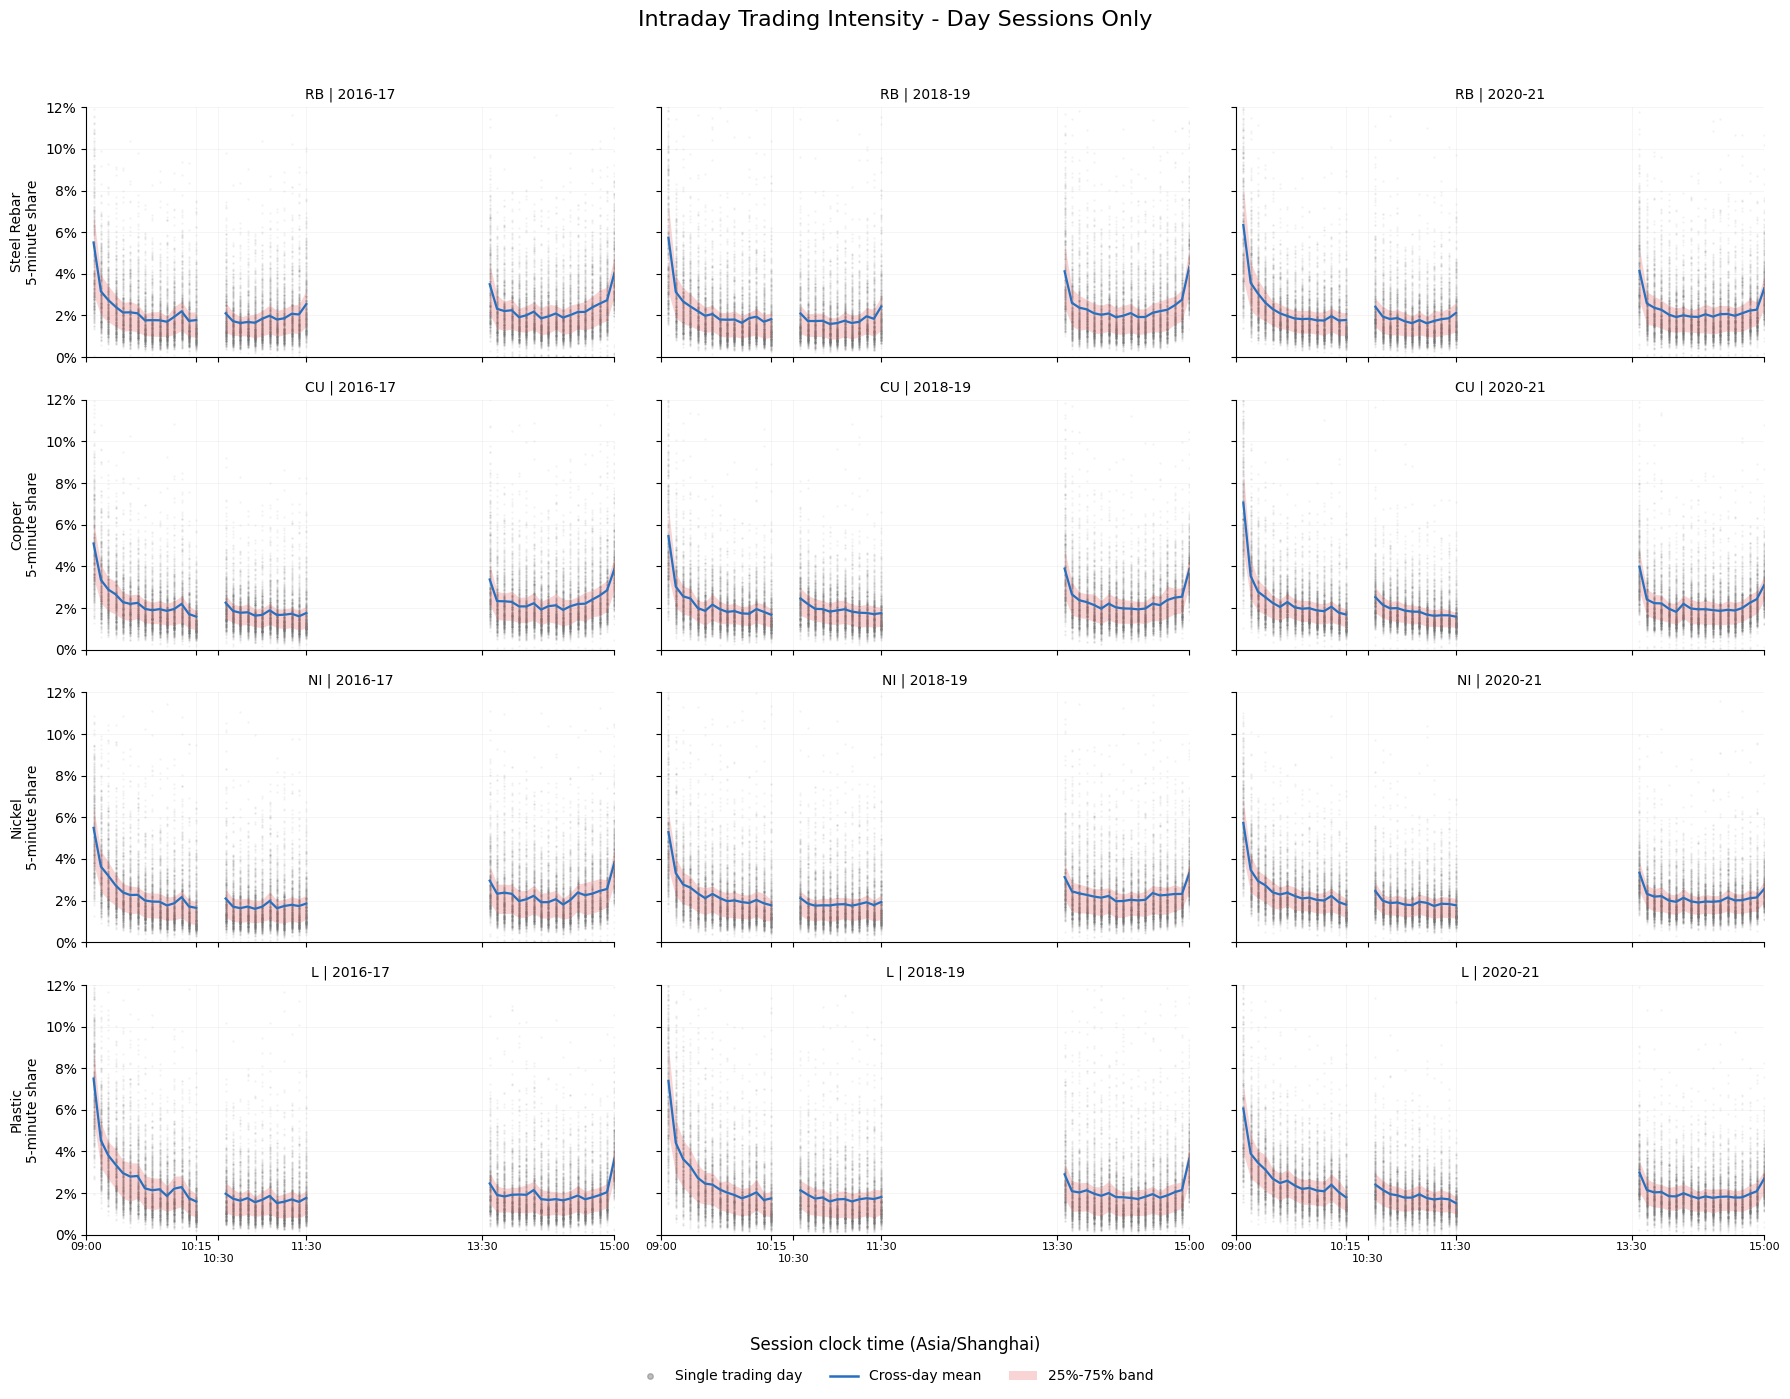

In [7]:
clipped_point_summary_df = (
    daily_five_minute_share_df.assign(
        is_above_figure_limit=(
            daily_five_minute_share_df["volume_share"] > FIGURE_Y_MAX_SHARE
        )
    )
    .groupby(
        ["exchange_code", "underlying_code", "period"],
        observed=True,
        as_index=False,
    )
    .agg(
        five_minute_points=("volume_share", "size"),
        points_above_figure_limit=("is_above_figure_limit", "sum"),
        maximum_daily_share=("volume_share", "max"),
    )
)
clipped_point_summary_df["share_above_figure_limit"] = (
    clipped_point_summary_df["points_above_figure_limit"]
    / clipped_point_summary_df["five_minute_points"]
)
display(clipped_point_summary_df)

figure15, axes15 = plt.subplots(
    len(PRODUCTS),
    len(PERIOD_LABELS),
    figsize=(18, 14),
    sharex=True,
    sharey=True,
)
panel_mean_line_count = {}
for row_index, product in enumerate(PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    for column_index, period_label in enumerate(PERIOD_LABELS):
        axis = axes15[row_index, column_index]
        panel_daily_df = daily_five_minute_share_df.loc[
            (daily_five_minute_share_df["exchange_code"] == product_key[0])
            & (daily_five_minute_share_df["underlying_code"] == product_key[1])
            & (daily_five_minute_share_df["period"] == period_label)
        ]
        panel_summary_df = intraday_summary_df.loc[
            (intraday_summary_df["exchange_code"] == product_key[0])
            & (intraday_summary_df["underlying_code"] == product_key[1])
            & (intraday_summary_df["period"] == period_label)
        ]
        if panel_daily_df.empty or panel_summary_df.empty:
            raise AssertionError(f"Figure 15 面板为空：{product_key}, {period_label}")

        axis.scatter(
            panel_daily_df["clock_minute"],
            panel_daily_df["volume_share"] * 100,
            color="#6F6F6F",
            s=2.0,
            alpha=0.10,
            linewidths=0,
            rasterized=True,
            zorder=1,
        )
        mean_line_count = 0
        for session_start_minute, session_summary_df in panel_summary_df.groupby(
            "session_start_minute",
            observed=True,
            sort=True,
        ):
            session_summary_df = session_summary_df.sort_values("clock_minute")
            x_values = session_summary_df["clock_minute"].to_numpy(dtype=float)
            q25_values = session_summary_df["q25_share"].to_numpy(dtype=float) * 100
            q75_values = session_summary_df["q75_share"].to_numpy(dtype=float) * 100
            mean_values = session_summary_df["mean_share"].to_numpy(dtype=float) * 100
            axis.fill_between(
                x_values,
                q25_values,
                q75_values,
                color="#E45756",
                alpha=0.25,
                linewidth=0,
                zorder=2,
            )
            axis.plot(
                x_values,
                mean_values,
                color="#276FBF",
                linewidth=1.6,
                zorder=3,
            )
            mean_line_count += 1

        panel_mean_line_count[(product_key[0], product_key[1], period_label)] = mean_line_count
        axis.set_xlim(CLOCK_TICKS[0], CLOCK_TICKS[-1])
        axis.set_ylim(0, FIGURE_Y_MAX_SHARE * 100)
        axis.set_xticks(CLOCK_TICKS, CLOCK_TICK_LABELS, rotation=0, ha="center")
        axis.tick_params(axis="x", labelsize=8, pad=2)
        axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        axis.grid(alpha=0.18, linewidth=0.5)
        axis.spines[["top", "right"]].set_visible(False)
        axis.set_title(f"{product['underlying_code']} | {period_label}", fontsize=10)
        if column_index == 0:
            axis.set_ylabel(f"{product['label']}\n5-minute share")

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color="#6F6F6F",
        alpha=0.45,
        markersize=4,
        label="Single trading day",
    ),
    Line2D([0], [0], color="#276FBF", linewidth=1.8, label="Cross-day mean"),
    Patch(facecolor="#E45756", alpha=0.25, label="25%-75% band"),
]
figure15.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.005),
)
figure15.suptitle("Intraday Trading Intensity - Day Sessions Only", fontsize=16, y=0.995)
figure15.supxlabel("Session clock time (Asia/Shanghai)", y=0.035)
figure15.tight_layout(rect=(0, 0.065, 1, 0.975))
plt.show()

## 验证

逐块成交量已经在计算时完成守恒和桶数核对。下面进一步检查四品种与三窗口覆盖、M/C 零行边界、每日日占比之和、完整两年、分位数人工复算，以及 12 个面板均含三个独立 Session 的均值曲线。

In [8]:
available_product_keys = set(
    daily_five_minute_share_df[["exchange_code", "underlying_code"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
if available_product_keys != set(PRODUCT_KEYS):
    raise AssertionError("四个可用分钟品种覆盖不完整")
unavailable_coverage_df = six_product_minute_coverage_df.loc[
    six_product_minute_coverage_df["underlying_code"].isin(["M", "C"])
]
if not (unavailable_coverage_df["minute_fact_rows"] == 0).all():
    raise AssertionError("M 或 C 已有分钟事实，应重新评估 Figure 15 覆盖")

volume_share_array = daily_five_minute_share_df["volume_share"].to_numpy(dtype=float)
if not np.isfinite(volume_share_array).all():
    raise AssertionError("五分钟成交量占比包含非有限值")
if ((volume_share_array < 0) | (volume_share_array > 1)).any():
    raise AssertionError("五分钟成交量占比不在 [0, 1]")
daily_share_sum = daily_five_minute_share_df.groupby(
    ["exchange_code", "underlying_code", "trading_date"],
    observed=True,
)["volume_share"].sum()
if not np.allclose(
    daily_share_sum.to_numpy(dtype=float),
    1.0,
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("同一品种交易日的五分钟占比之和不为 1")
if len(zero_volume_days_df) != 0:
    raise AssertionError("论文样本出现日盘总成交量为零的交易日")
if not np.allclose(
    chunk_coverage_df["volume_reconciliation_difference"].to_numpy(dtype=float),
    0.0,
    rtol=0,
    atol=1e-8,
):
    raise AssertionError("分块一分钟与五分钟成交量对账差异非零")

expected_panel_count = len(PRODUCTS) * len(PERIOD_LABELS)
if len(period_coverage_df) != expected_panel_count:
    raise AssertionError(f"品种—窗口覆盖应为 {expected_panel_count}，实际 {len(period_coverage_df)}")
if not period_coverage_df["is_complete_two_year_period"].all():
    raise AssertionError("存在没有覆盖两个日历年的 Figure 15 面板")
if period_coverage_df["five_minute_observations"].min() <= 0:
    raise AssertionError("Figure 15 面板没有五分钟观测")

manual_group_key = intraday_summary_df.iloc[0]
manual_share = daily_five_minute_share_df.loc[
    (daily_five_minute_share_df["exchange_code"] == manual_group_key["exchange_code"])
    & (daily_five_minute_share_df["underlying_code"] == manual_group_key["underlying_code"])
    & (daily_five_minute_share_df["period"] == manual_group_key["period"])
    & (
        daily_five_minute_share_df["session_start_minute"]
        == manual_group_key["session_start_minute"]
    )
    & (daily_five_minute_share_df["clock_minute"] == manual_group_key["clock_minute"]),
    "volume_share",
]
manual_statistics = np.array(
    [
        manual_share.mean(),
        manual_share.quantile(0.25),
        manual_share.median(),
        manual_share.quantile(0.75),
    ],
    dtype=float,
)
reported_statistics = np.array(
    [
        manual_group_key["mean_share"],
        manual_group_key["q25_share"],
        manual_group_key["median_share"],
        manual_group_key["q75_share"],
    ],
    dtype=float,
)
if manual_group_key["day_count"] != manual_share.size:
    raise AssertionError("时点跨日样本数复算不一致")
if not np.allclose(manual_statistics, reported_statistics, rtol=1e-12, atol=1e-12):
    raise AssertionError("均值或分位数人工复算不一致")
if not (intraday_summary_df["q25_share"] <= intraday_summary_df["q75_share"]).all():
    raise AssertionError("25% 分位大于 75% 分位")
if (intraday_summary_df[["mean_share", "q75_share"]].max().max() > FIGURE_Y_MAX_SHARE):
    raise AssertionError("图表纵轴上限截断了均值或 75% 分位带")

if len(axes15.flat) != expected_panel_count:
    raise AssertionError("Figure 15 面板数不正确")
if set(panel_mean_line_count.values()) != {3}:
    raise AssertionError("Figure 15 面板没有三个独立日盘 Session 均值段")
if any(len(axis.collections) < 4 for axis in axes15.flat):
    raise AssertionError("Figure 15 存在缺少散点或分位带的面板")
if any(len(axis.lines) != 3 for axis in axes15.flat):
    raise AssertionError("Figure 15 存在均值曲线数量不正确的面板")

print(
    f"validation_ok: {len(available_product_keys)} products, "
    f"{len(period_coverage_df)} product-period panels, "
    f"{daily_five_minute_share_df['trading_date'].nunique()} distinct trading dates, "
    f"{len(daily_five_minute_share_df):,} daily five-minute points, "
    f"{int(clipped_point_summary_df['points_above_figure_limit'].sum()):,} points above the {FIGURE_Y_MAX_SHARE:.0%} display limit"
)

validation_ok: 4 products, 12 product-period panels, 1461 distinct trading dates, 262,980 daily five-minute points, 416 points above the 12% display limit


## 如何解释结果

- 蓝线在每段 Session 开始后较高，反映开盘时订单积压和信息吸收；临近 10:15、11:30、15:00 的抬升可用 closing_to_middle_ratio 定量阅读。
- 红带越宽，表示该五分钟时点在不同交易日之间的成交量分配越不稳定；红带不是置信区间，而是日间经验四分位区间。
- 各面板先除以自己的当日日盘总成交量，因此比较的是日内形状，不是不同年份的绝对成交量增长。
- 当前统一 12% 图轴完整覆盖均值和四分位带；少数极端交易日灰点仍可能超过上限，完整数值保留在数据框和统计中，裁切比例由输出表明确报告。
- M、C 没有分钟事实，本轮不展示；这不代表它们没有相同日内形态，只代表当前湖仓无法检验。
- 结果是描述性的。开收盘成交集中可以与算法执行并存，但不足以单独识别算法交易或监管变化的因果影响。